# TensorFlow 2 quickstart for beginners

In [38]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.callbacks import TensorBoard
import datetime
import subprocess

In [41]:
!chmod +x ./launch_tensorboard.py
!python ./launch_tensorboard.py &

chmod: cannot access './launch_tensorboard.py': No such file or directory


OSError: Background processes not supported.

In [25]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

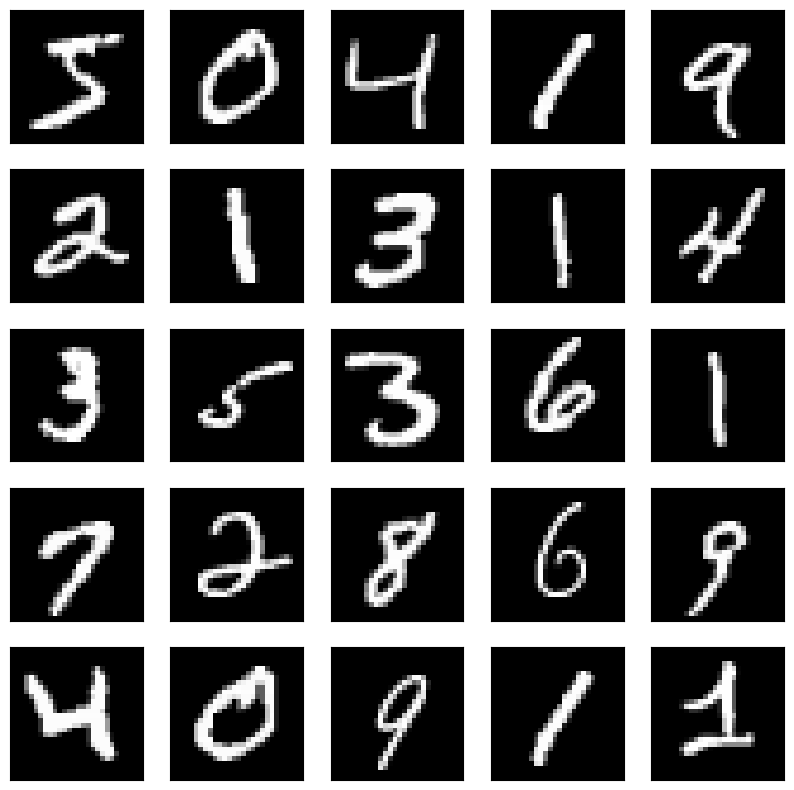

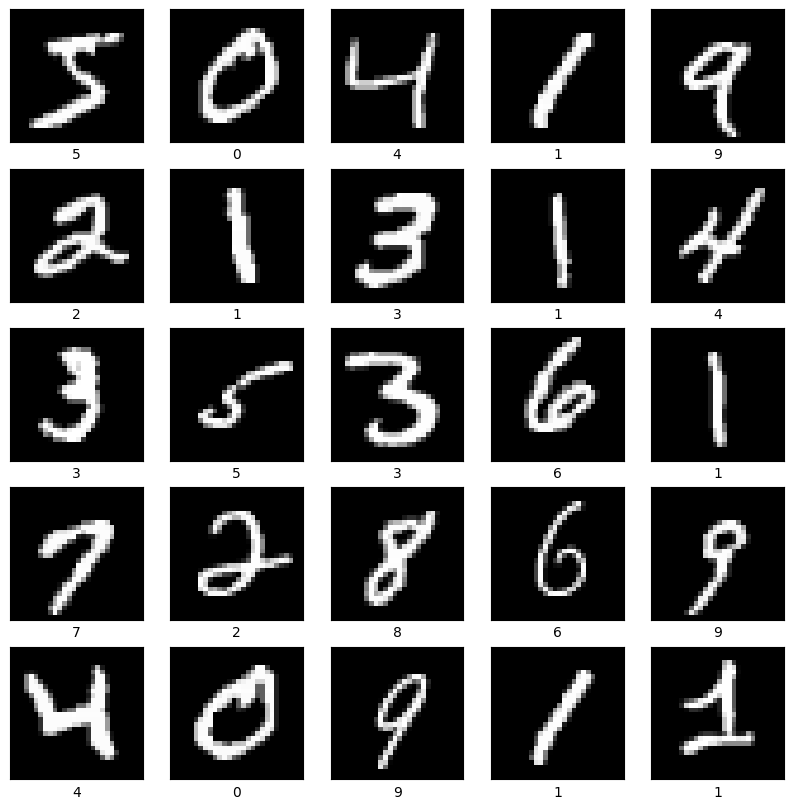

In [26]:
def show_mnist_without_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")

def show_mnist_with_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")
        plt.xlabel(y_train[i])

show_mnist_without_label()
show_mnist_with_label()

In [27]:
def create_model(input_shape1, input_shape2, output_shape, activation):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(input_shape1, input_shape2)),
      tf.keras.layers.Dense(output_shape, activation=activation),
      tf.keras.layers.Dropout(0.4),
      tf.keras.layers.Dense(10)
    ])
    return model

mymodel = create_model(28, 28, 128, 'relu')
mymodel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
predictions = mymodel(x_train[:1]).numpy()
predictions

array([[ 0.17735101,  0.18340674,  0.3087447 , -0.21214387,  0.20295547,
         0.31827998,  0.59703773,  0.6053347 , -0.12230017,  0.07600163]],
      dtype=float32)

In [29]:
tf.nn.softmax(predictions).numpy()

array([[0.09344478, 0.09401237, 0.10656598, 0.06329939, 0.09586828,
        0.10758698, 0.14217481, 0.14335933, 0.06924975, 0.0844383 ]],
      dtype=float32)

In [30]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [31]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.2294557)

In [32]:
mymodel.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [33]:
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

In [34]:
mymodel.fit(
    x_train, 
    y_train, 
    epochs=30, 
    validation_split=0.25, 
    verbose=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/30
1407/1407 - 4s - 3ms/step - accuracy: 0.8807 - loss: 0.4037 - val_accuracy: 0.9458 - val_loss: 0.1879
Epoch 2/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9371 - loss: 0.2151 - val_accuracy: 0.9575 - val_loss: 0.1421
Epoch 3/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9499 - loss: 0.1684 - val_accuracy: 0.9633 - val_loss: 0.1218
Epoch 4/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9564 - loss: 0.1425 - val_accuracy: 0.9664 - val_loss: 0.1123
Epoch 5/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9615 - loss: 0.1283 - val_accuracy: 0.9686 - val_loss: 0.1051
Epoch 6/30
1407/1407 - 4s - 3ms/step - accuracy: 0.9636 - loss: 0.1152 - val_accuracy: 0.9692 - val_loss: 0.1026
Epoch 7/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9663 - loss: 0.1072 - val_accuracy: 0.9705 - val_loss: 0.1015
Epoch 8/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9692 - loss: 0.0963 - val_accuracy: 0.9723 - val_loss: 0.0937
Epoch 9/30
1407/1407 - 4s - 3ms/step - accuracy: 0.9719 - loss: 0.0899 - val_accuracy: 0.9713 - 

KeyboardInterrupt: 

In [ ]:
mymodel.evaluate(x_test,  y_test, verbose=2)

In [ ]:
#loss
plt.plot(mymodel.history.history['loss'])
plt.plot(mymodel.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

#accuracy
plt.plot(mymodel.history.history['accuracy'])
plt.plot(mymodel.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

In [ ]:
print(f"Répertoire actuel : {os.getcwd()}")
os.makedirs('model', exist_ok=True)
mymodel.save(os.path.join('model', 'my_model.keras'))

In [ ]:
print(os.listdir('/tf'))

In [ ]:
probability_model = tf.keras.Sequential([
  mymodel,
  tf.keras.layers.Softmax()
])

In [ ]:
probability_model(x_test[:5])